In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error

In [2]:
os.chdir("C:/Python/Datasets")
df = pd.read_csv("monthly-milk-production-pounds-p.csv", index_col=0)

In [3]:
df.shape

(168, 1)

In [4]:
y = df['Milk']
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

In [5]:
y_train.shape, y_test.shape

((156,), (12,))

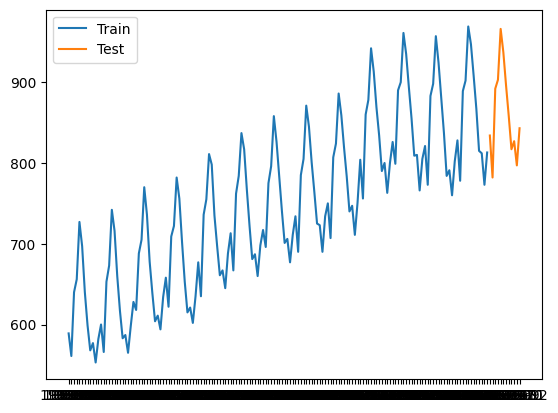

In [6]:
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.legend()
plt.show()

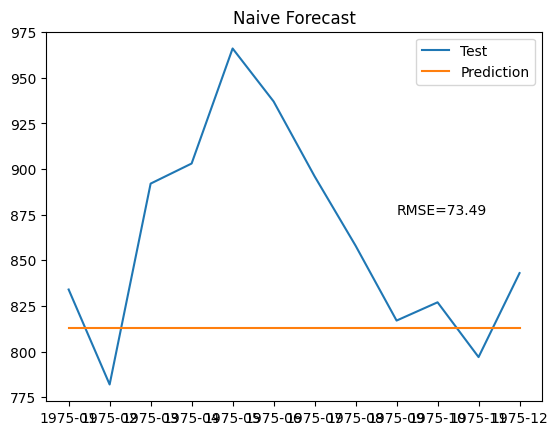

In [7]:
last_obs = y_train.iloc[-1]
y_pred = pd.Series(last_obs.repeat(len(y_test)), index=y_test.index)
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("Naive Forecast")
plt.legend()
plt.show()

In [8]:
root_mean_squared_error(y_test, y_pred)

73.4903621799031

#### Seasonal Naive Forecast

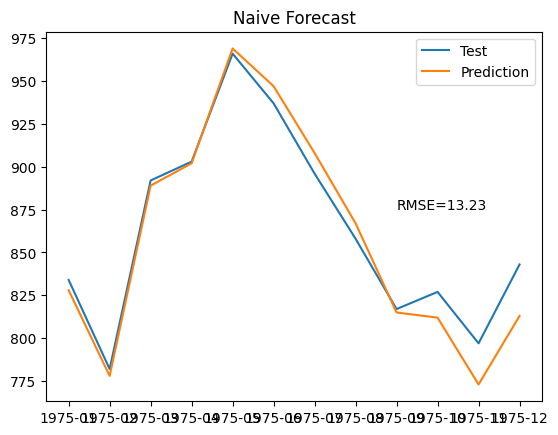

In [10]:
y_pred = y_train.iloc[-12:]
y_pred.index = y_test.index
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.title("Naive Forecast")
plt.legend()
plt.show()

In [11]:
root_mean_squared_error(y_test, y_pred)

13.231905884389192

#### Window Average Forecast

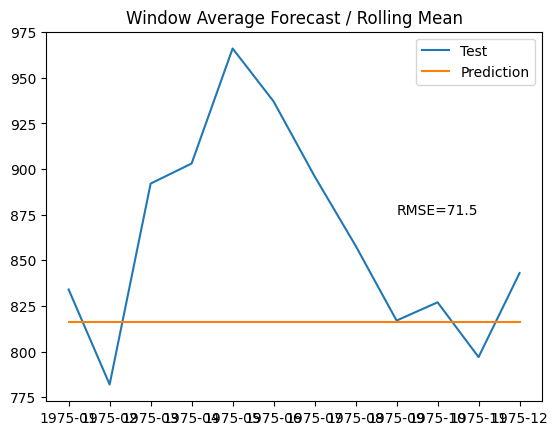

In [13]:
span=5
roll_mean = y_train.iloc[-span:].mean()
y_pred = pd.Series(roll_mean.repeat(len(y_test)), index=y_test.index)
plt.plot(y_test, label="Test")
plt.plot(y_pred, label="Prediction")
plt.title("Window Average Forecast / Rolling Mean")
error = np.round(root_mean_squared_error(y_test, y_pred) ,2)
plt.text(8, 875, "RMSE="+str(error))
plt.legend()
plt.show()

#### Centered Rolling Mean

Not used for forcasting. Used for just visualization purpose.

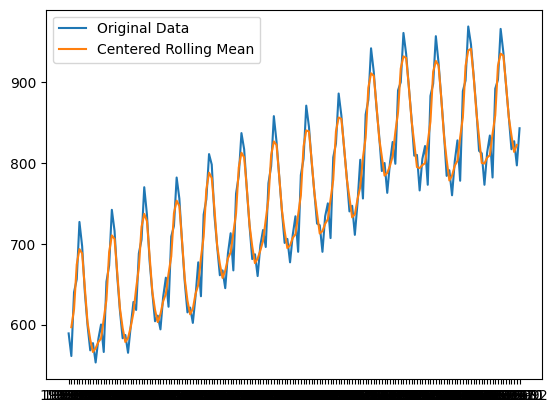

In [16]:
span = 3
plt.plot(y, label='Original Data')
plt.plot(y.rolling(span,center=True).mean(), label='Centered Rolling Mean')
plt.legend()
plt.show()